In [106]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.connection import get_db_connection


conn = get_db_connection()

if conn:
    query_tables = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'raw';"
    tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
    
    data = {}

    for table in tables:
        data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)
        print(f"Таблица '{table}' загружена! (строк: {len(data[table])})")
    
    conn.close()
else:
    print("Ошибка подключения к СУБД")



Успешно: Подключение к СУБД установлено.
Таблица 'app' загружена! (строк: 12)
Таблица 'bank_db' загружена! (строк: 36)


In [107]:
df_finance = data['bank_db'] 
df_apps = data['app'][['id', 'rank']]

final = pd.merge(df_finance, df_apps, on='id', how='inner')


In [108]:
print(final.columns.tolist())

['id', 'bank', 'year', '%income', '%expence', 'net%income', 'com_income', 'com_outcome', 'net_com_income', 'FX income', 'op_expence', 'net_profit', 'loan', 'deposit', 'assets', 'capital', 'capital_adequacy', 'NPL', 'rank']


In [109]:
final.head()


,id,bank,year,%income,%expence,net%income,com_income,com_outcome,net_com_income,FX income,op_expence,net_profit,loan,deposit,assets,capital,capital_adequacy,NPL,rank
0,1,Капитал,2023,448329,65529,382800,151465,65529,85936,142829,369796,73804,2557343,2751804,4854278,10273358,25.5,118699,3.73
1,1,Капитал,2024,518491,210451,308040,180903,86985,93918,296684,491910,256108,3151148,2504151,5536169,1161490,28.8,107522,3.73
2,1,Капитал,2025,717896,319996,397900,2068281,926252,1142029,757125,1042493,436848,3702325,4276537,11139747,5403777,94.5,16310,3.73
3,2,MBank,2023,3847661,472067,3375594,3139468,4013911,-874443,5032491,3581821,3597929,18455685,46268154,60479934,8745843,24.4,649007,4.67
4,2,MBank,2024,7383101,1793221,5589880,5345154,4354844,990310,7748120,6236134,6488968,44610965,74351339,102257832,15194805,22.4,1437216,4.67


In [110]:
final.drop(['id'], axis=1).describe()

,year,%income,%expence,net%income,com_income,com_outcome,net_com_income,FX income,op_expence,net_profit,loan,deposit,assets,capital,capital_adequacy,NPL,rank
count,36.000000,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,36.000000,3.600000e+01,36.000000
mean,2024.000000,4.632305e+06,1.804554e+06,2.827751e+06,1.546859e+06,1.182829e+06,3.640297e+05,2.263846e+06,3.368485e+06,2.334309e+06,2.601894e+07,4.802339e+07,6.680484e+07,1.092210e+07,23.151389,1.423793e+06,4.220833
std,0.828079,3.138402e+06,1.675767e+06,2.127233e+06,1.467958e+06,1.171705e+06,6.202875e+05,2.394702e+06,2.642250e+06,2.411608e+06,1.964638e+07,4.230604e+07,5.950555e+07,1.372905e+07,14.793775,1.350601e+06,0.430431
min,2023.000000,4.483290e+05,6.552900e+04,-6.770410e+05,1.514650e+05,6.552900e+04,-8.744430e+05,1.428290e+05,2.313370e+05,6.548800e+04,2.557343e+06,1.334432e+06,4.854278e+06,8.170080e+05,13.500000,1.631000e+04,3.500000
25%,2023.000000,1.787200e+06,7.534912e+05,8.901798e+05,4.342612e+05,3.792430e+05,6.453750e+04,5.183052e+05,1.241615e+06,2.650238e+05,9.881109e+06,1.076026e+07,1.772734e+07,4.189540e+06,16.100000,4.112812e+05,3.920000
50%,2024.000000,4.372873e+06,1.422766e+06,2.680073e+06,1.140821e+06,8.148760e+05,2.533030e+05,1.257244e+06,2.971335e+06,1.948064e+06,2.166113e+07,4.474103e+07,5.844009e+07,9.070410e+06,19.200000,8.571230e+05,4.185000
75%,2025.000000,6.204290e+06,2.167605e+06,3.998875e+06,2.068615e+06,1.415802e+06,5.796772e+05,3.605918e+06,4.436235e+06,3.060150e+06,3.636500e+07,6.259004e+07,8.725723e+07,1.213868e+07,24.500000,2.152860e+06,4.677500
max,2025.000000,1.369702e+07,8.328386e+06,7.613982e+06,7.158875e+06,4.354844e+06,2.804031e+06,7.958722e+06,1.158713e+07,8.322179e+06,8.367159e+07,1.610227e+08,2.656848e+08,8.114297e+07,94.500000,5.328545e+06,4.800000


In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# очистка
final.columns = final.columns.str.strip()
final = final.fillna(0)

# 3 year mean 
avg = final.groupby('bank').mean(numeric_only=True).reset_index()

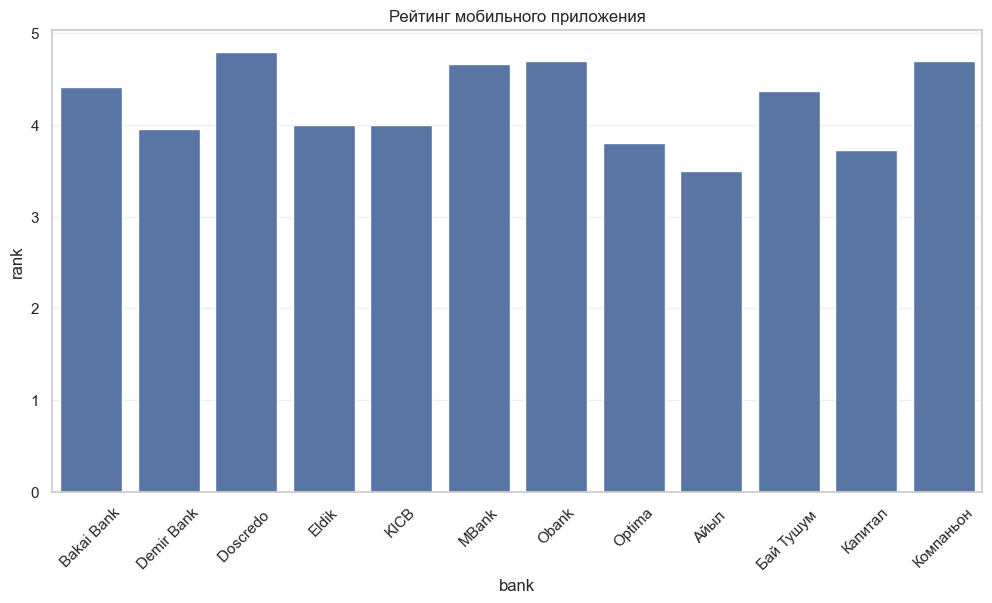

In [119]:
#Анализ цифровизации или приложения банка и их рейтинг
plt.figure(figsize=(12,6))
sns.barplot(data=avg, x='bank', y='rank')
plt.xticks(rotation=45)
plt.title("Рейтинг мобильного приложения")
plt.show()

#Банки с высоким рейтингом мобильного приложения обеспечивают более удобный пользовательский опыт

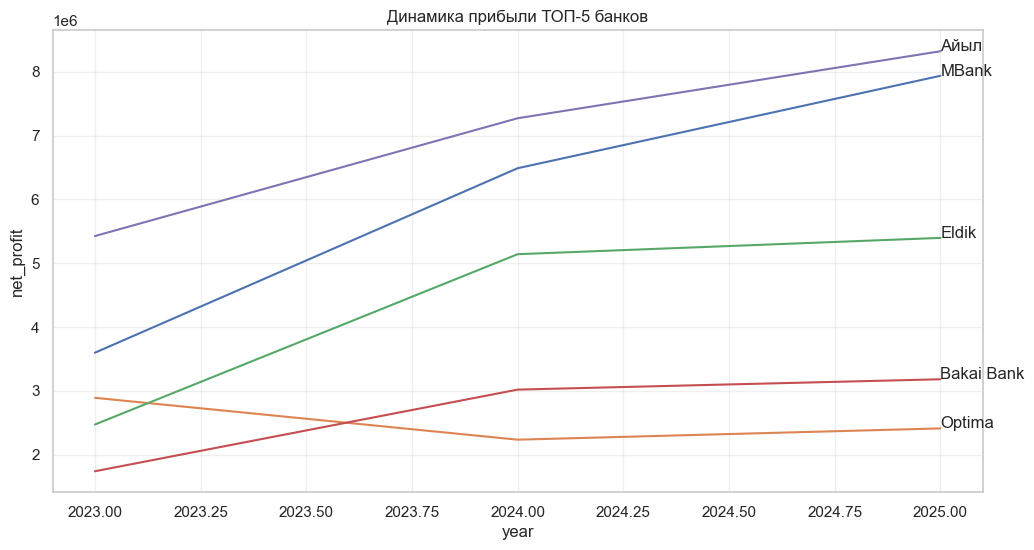

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df_top, x='year', y='net_profit', hue='bank', legend=False)

for bank in top_banks:
    subset = df[df['bank'] == bank]
    last = subset[subset['year'] == subset['year'].max()]
    
    plt.text(
        last['year'].values[0],
        last['net_profit'].values[0],
        bank
    )

plt.title("Динамика прибыли ТОП-5 банков")
plt.show()



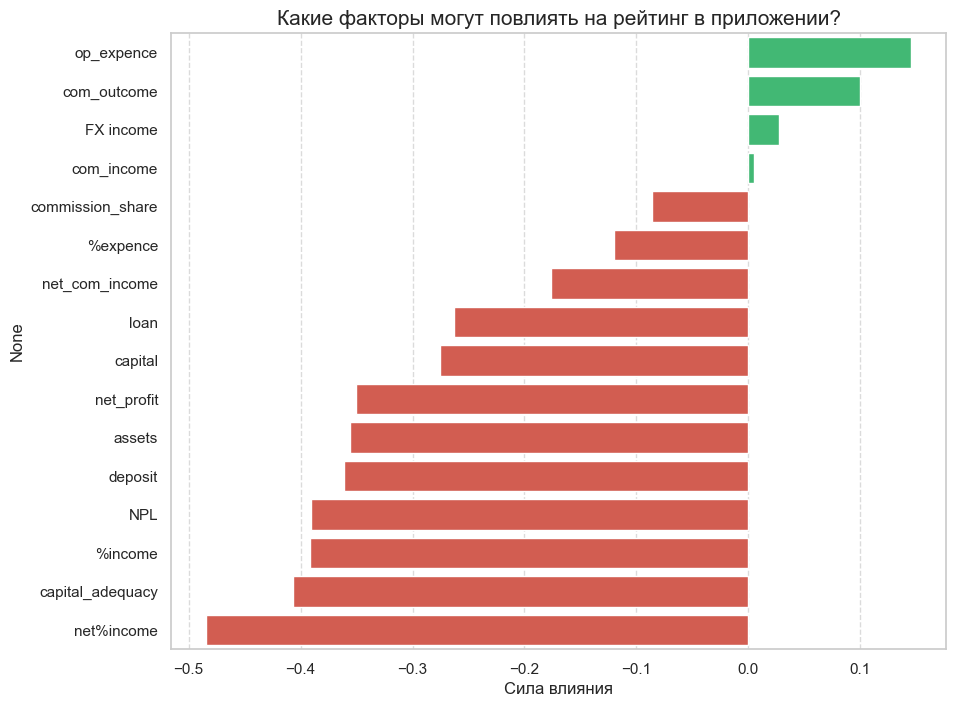

In [121]:
rank_impact = final.drop(['id', 'year'], axis=1).corr(numeric_only=True)[['rank']]
rank_impact = rank_impact.sort_values(by='rank', ascending=False).drop('rank') 

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in rank_impact['rank']] 

sns.barplot(x=rank_impact['rank'], y=rank_impact.index, palette=colors)
plt.title('Какие факторы могут повлиять на рейтинг в приложении?', fontsize=15)
plt.xlabel('Сила влияния')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

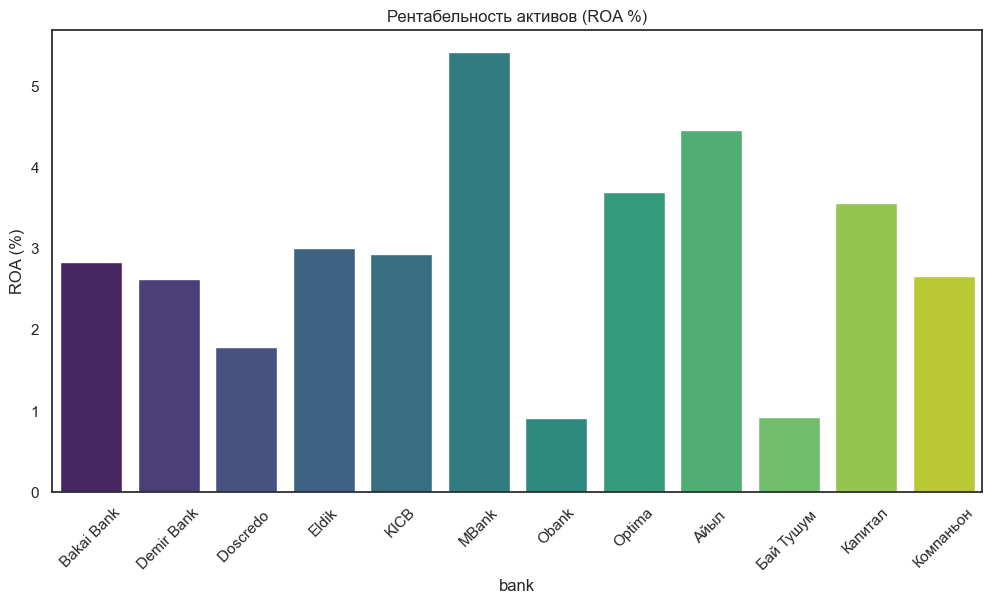

In [ ]:
avg['roa'] = (avg['net_profit'] / avg['assets']) * 100

plt.figure(figsize=(12,6))
sns.barplot(data=avg.reset_index(), x='bank', y='roa', palette='viridis') 

plt.xticks(rotation=45)
plt.title("Рентабельность активов (ROA %)")
plt.ylabel("ROA (%)")
plt.show()

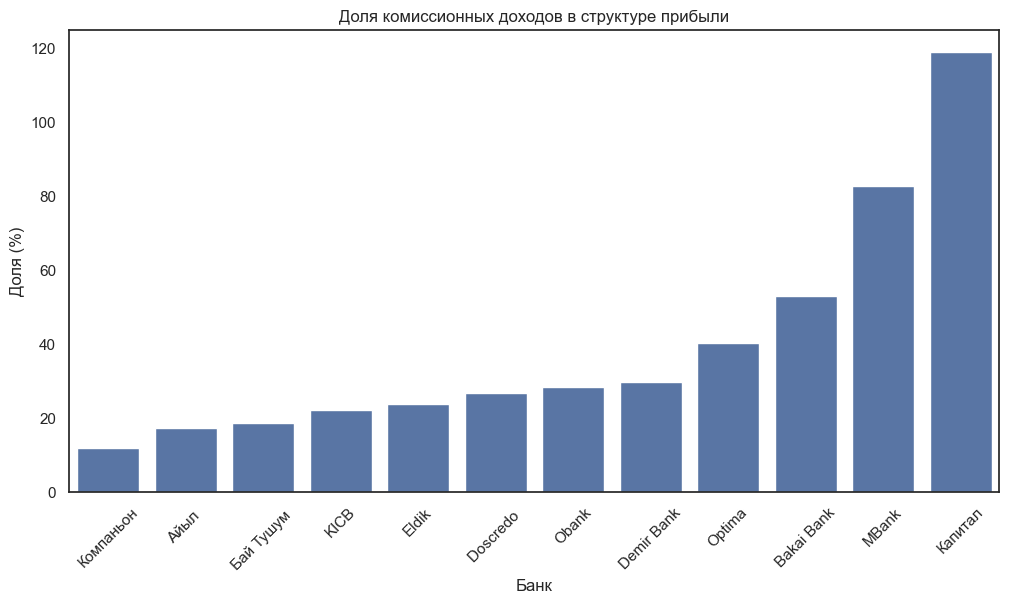

In [133]:
# Сортируем от меньшего к большему (самые выгодные — слева)
df_sorted_fees = avg.sort_values('commission_share')

plt.figure(figsize=(12,6))
sns.barplot(data=df_sorted_fees, x='bank', y='commission_share')

plt.xticks(rotation=45)
plt.title("Доля комиссионных доходов в структуре прибыли")
plt.ylabel("Доля (%)")
plt.xlabel("Банк")
plt.show()

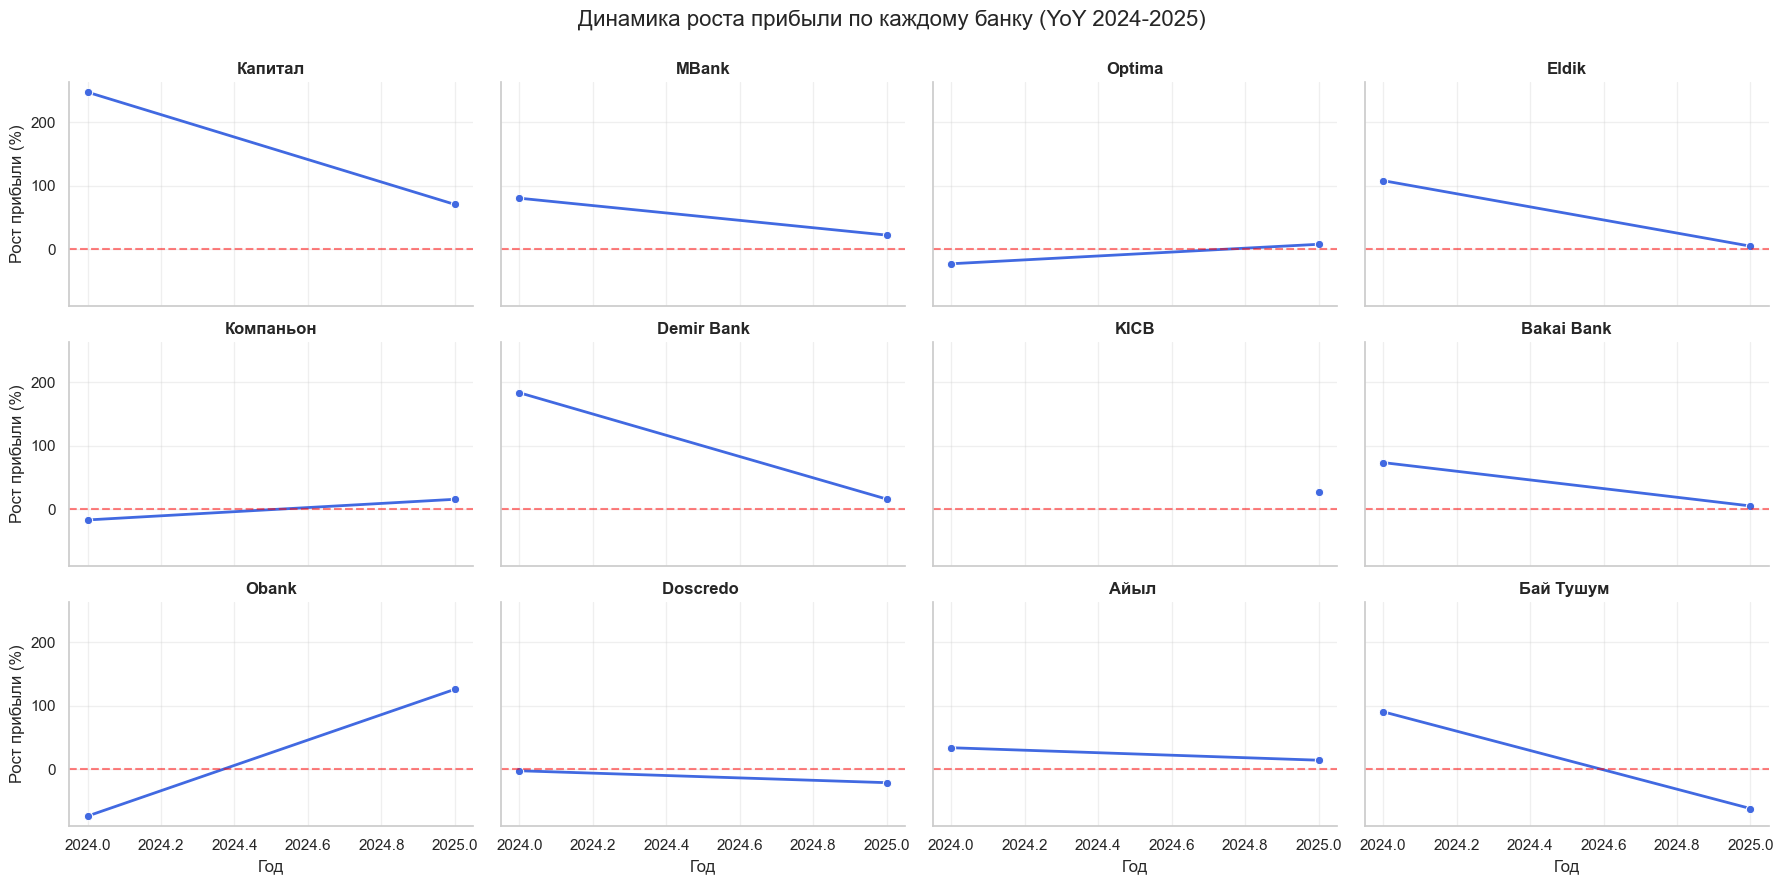

In [124]:
# Настройка стиля
sns.set_theme(style="whitegrid")

# Создаем сетку графиков: по одному на каждый банк
g = sns.FacetGrid(growth_data, col="bank", col_wrap=4, height=3, aspect=1.5)

# Рисуем линии роста
g.map(sns.lineplot, "year", "profit_growth_pct", marker="o", color="royalblue", linewidth=2)

# Добавляем красную пунктирную линию на уровне 0 (граница прибыли и убытка)
g.map(plt.axhline, y=0, ls="--", c="red", alpha=0.5)

# Настройка заголовков и осей
g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Год", "Рост прибыли (%)")

# Общий заголовок
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Динамика роста прибыли по каждому банку (YoY 2024-2025)', fontsize=16)

plt.show()

<Figure size 1200x700 with 0 Axes>

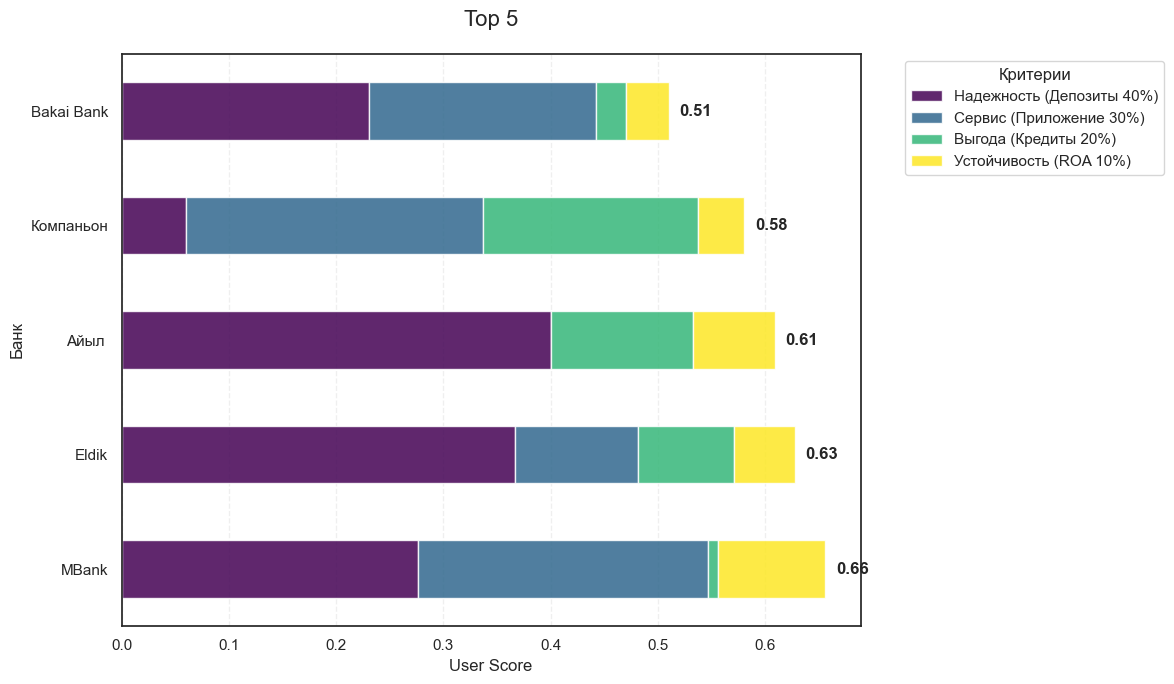

In [166]:

final['expense_ratio'] = (final['%expence'] / final['%income'].replace(0, 1)) * 100
final['commission_share'] = (final['com_income'] / final['%income'].replace(0, 1)) * 100
final['roa'] = (final['net_profit'] / final['assets'].replace(0, 1)) * 100

# 4. Агрегация данных по банкам (среднее значение)
avg = final.groupby('bank').mean(numeric_only=True).reset_index()

# балл "инвертированной комиссии"
avg['inv_commissions'] = 1 / (avg['commission_share'] + 0.001)

# Функция для приведения значений к шкале от 0 до 1 (Нормализация)
def scale(col):
    if col.max() == col.min(): return 0.5
    return (col - col.min()) / (col.max() - col.min())

avg['s_trust'] = scale(avg['assets']) * 0.40           # Надежность (40%)
avg['s_app'] = scale(avg['rank']) * 0.30                # Популярность/Приложение (30%)
avg['s_benefit'] = scale(avg['inv_commissions']) * 0.20  # Низкие комиссии (20%)
avg['s_profit'] = scale(avg['roa']) * 0.10              # Стабильность прибыли (10%)

avg['user_score'] = avg['s_trust'] + avg['s_app'] + avg['s_benefit'] + avg['s_profit']

top5_user = avg.sort_values(by='user_score', ascending=False).head(5)

plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

plot_df = top5_user.set_index('bank')[['s_trust', 's_app', 's_benefit', 's_profit']]
plot_df.columns = ['Надежность (Депозиты 40%)', 'Сервис (Приложение 30%)', 'Выгода (Кредиты 20%)', 'Устойчивость (ROA 10%)']

ax = plot_df.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis', alpha=0.85, edgecolor='white')

plt.title('Top 5', fontsize=16, pad=20)
plt.xlabel('User Score')
plt.ylabel('Банк')
plt.legend(title="Критерии", bbox_to_anchor=(1.05, 1), loc='upper left')

for i, total in enumerate(top5_user['user_score']):
    plt.text(total + 0.01, i, f'{total:.2f}', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()